In [7]:
from path import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
def make_table(model_filenames, prompt_dirs):
    root = Path("/shared/results/common/z1211445/UNBRANDING/results/eval_brand_benchmark")
    accs = []
    corrs = []
    hallucination_percentages = []
    for prompt in prompt_dirs:
        model_accs = []
        model_corrs = []
        model_hallucinations = []
        for model in model_filenames:
            path = root / prompt / model
            if not path.exists():
                model_corrs.append(np.nan)
                model_accs.append(np.nan)
                print(f"File not found: {path}, skipping.")
                continue
            path = root / prompt / model
            df = pd.read_csv(path)
            df['brand_match'] = (df['brand'] == df['predicted_brand']).astype(int)
            corr = df['gt_label'].corr(df['brand_match'])
            count = (df['brand_match'] == df['gt_label']).sum()
            accuracy = count / len(df)
            hall_percent = (
                                df[(df["gt_label"] == 0) & (df["predicted_brand"] != "NO_BRAND")].shape[0]
                                / df[df["gt_label"] == 0].shape[0]
                            ) * 100
            print(f"Model: {model}, Prompt: {prompt}, Pearson correlation: {corr:.4f}, Accuracy: {accuracy:.4f}")
            model_corrs.append(corr)
            model_accs.append(accuracy)
            model_hallucinations.append(hall_percent)
            
        corrs.append(model_corrs)
        accs.append(model_accs)
        hallucination_percentages.append(model_hallucinations)
    return accs, corrs, hallucination_percentages

In [8]:
prompt_dirs = ["vlm_brand_prompt1", 
               "vlm_brand_prompt2", 
               "vlm_brand_prompt3", 
               "vlm_brand_prompt4", 
               "vlm_brand_prompt5"]
model_filenames = [
    "eval_google__gemma-3-4b-it_rank0.csv",
    "eval_google__gemma-3-12b-it_rank0.csv",
    "eval_llava-hf__llava-1.5-7b-hf_rank0.csv",
    "eval_llava-hf__llava-1.5-13b-hf_rank0.csv",
    "eval_mistralai__Ministral-3-3B-Instruct-2512_rank0.csv",
    "eval_mistralai__Ministral-3-8B-Instruct-2512_rank0.csv",
    "eval_mistralai__Ministral-3-14B-Instruct-2512_rank0.csv",
    "eval_Qwen__Qwen3-VL-4B-Instruct_rank0.csv",
    "eval_Qwen__Qwen3-VL-8B-Instruct_rank0.csv",
    "eval_Qwen__Qwen3-VL-8B-Thinking_rank0.csv",
]
models_short_filenames = ["gemma-3-4b",
                            "gemma-3-12b",
                          "llava-1.5-7b",
                          "llava-1.5-13b",
                          "Ministral-3-3B-Instruct",
                          "Ministral-3-8B-Instruct",
                          "Ministral-3-14B-Instruct",
                          "Qwen3-VL-4B-Instruct",
                          "Qwen3-VL-8B-Instruct",
                          "Qwen3-VL-8B-Thinking"]


Model: eval_google__gemma-3-4b-it_rank0.csv, Prompt: vlm_brand_prompt1, Pearson correlation: 0.6639, Accuracy: 0.8249
Model: eval_google__gemma-3-12b-it_rank0.csv, Prompt: vlm_brand_prompt1, Pearson correlation: 0.7301, Accuracy: 0.8599
Model: eval_llava-hf__llava-1.5-7b-hf_rank0.csv, Prompt: vlm_brand_prompt1, Pearson correlation: 0.7257, Accuracy: 0.8629
Model: eval_llava-hf__llava-1.5-13b-hf_rank0.csv, Prompt: vlm_brand_prompt1, Pearson correlation: 0.6833, Accuracy: 0.8354
Model: eval_mistralai__Ministral-3-3B-Instruct-2512_rank0.csv, Prompt: vlm_brand_prompt1, Pearson correlation: 0.7141, Accuracy: 0.8523
Model: eval_mistralai__Ministral-3-8B-Instruct-2512_rank0.csv, Prompt: vlm_brand_prompt1, Pearson correlation: 0.7595, Accuracy: 0.8785
Model: eval_mistralai__Ministral-3-14B-Instruct-2512_rank0.csv, Prompt: vlm_brand_prompt1, Pearson correlation: 0.7759, Accuracy: 0.8873
Model: eval_Qwen__Qwen3-VL-4B-Instruct_rank0.csv, Prompt: vlm_brand_prompt1, Pearson correlation: 0.7854, Acc

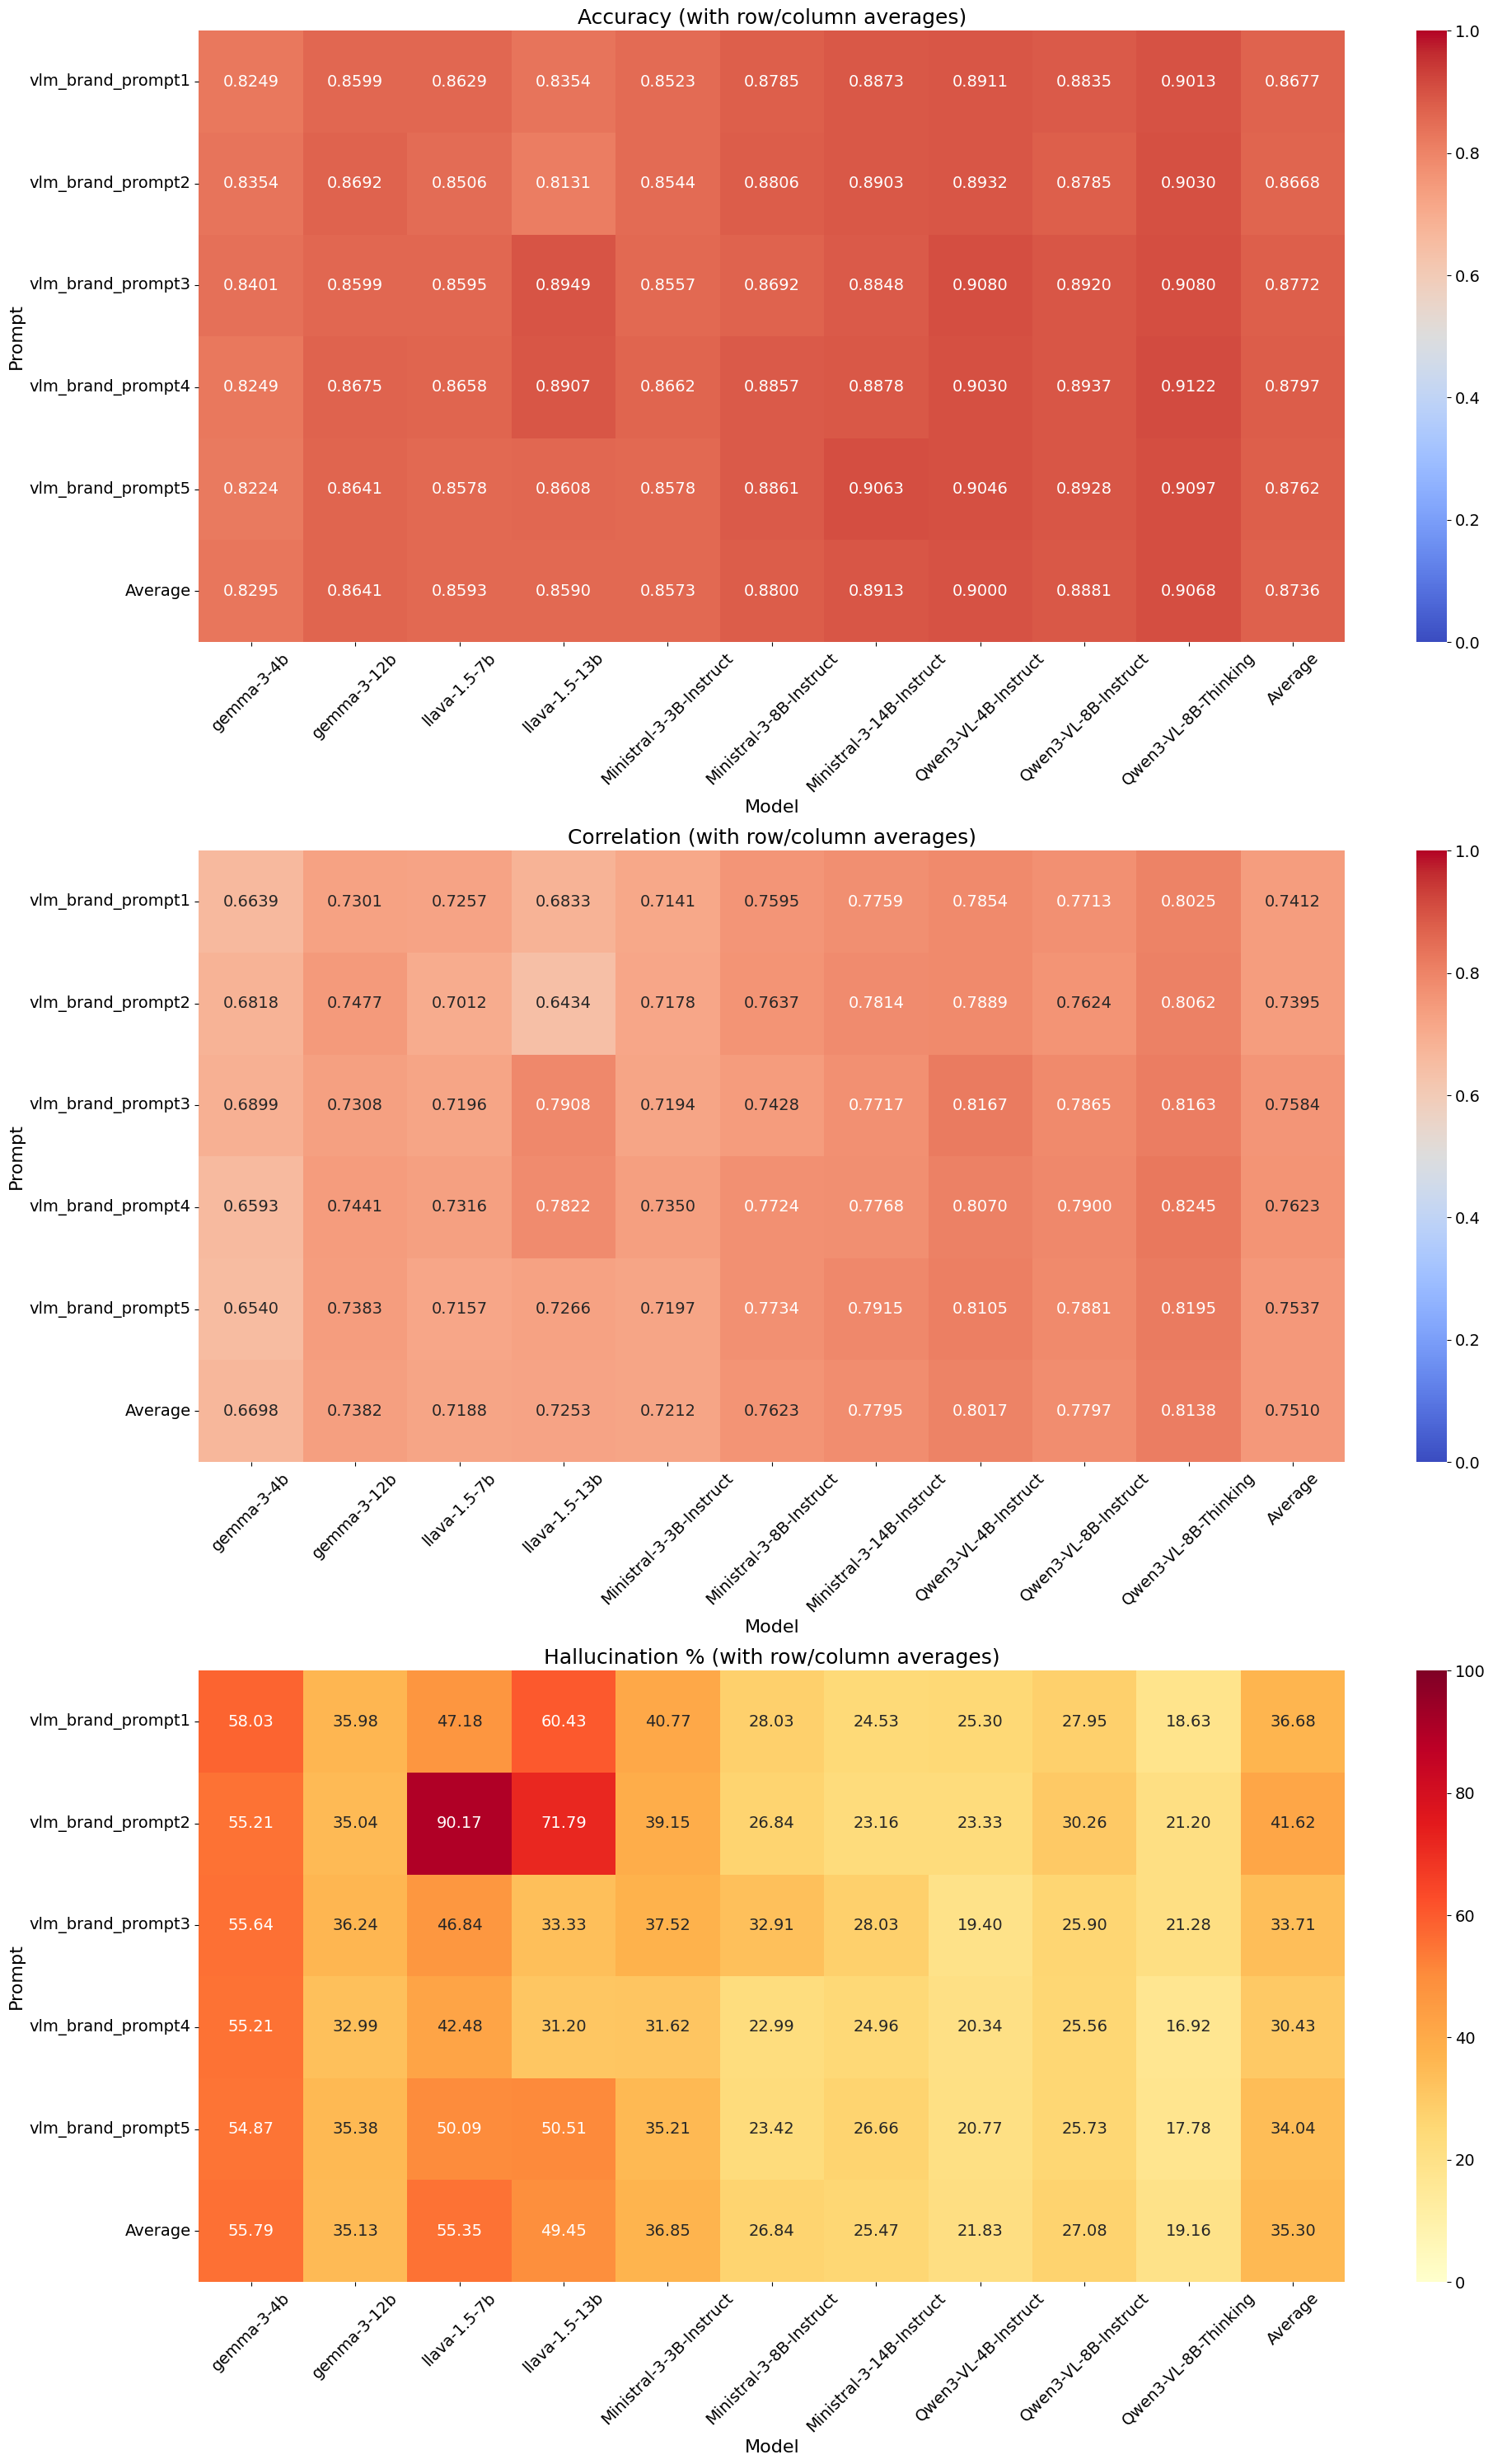

In [9]:
def with_averages(df):
    df_avg = df.copy()
    df_avg["Average"] = df_avg.mean(axis=1, skipna=True)          # row-wise average
    df_avg.loc["Average"] = df_avg.mean(axis=0, skipna=True)      # column-wise average
    return df_avg

# Recompute to also get hallucination percentages
accs, corrs, hallucination_percentages = make_table(model_filenames, prompt_dirs)

accs_df = pd.DataFrame(accs, columns=models_short_filenames, index=prompt_dirs)
corrs_df = pd.DataFrame(corrs, columns=models_short_filenames, index=prompt_dirs)
hall_df = pd.DataFrame(hallucination_percentages, columns=models_short_filenames, index=prompt_dirs)

accs_plot = with_averages(accs_df)
corrs_plot = with_averages(corrs_df)
hall_plot = with_averages(hall_df)

fig, axes = plt.subplots(3, 1, figsize=(20, 30))

# font sizes
annot_fs = 14
tick_fs = 14
title_fs = 18
label_fs = 16

sns.heatmap(
    accs_plot, annot=True, fmt=".4f", cmap="coolwarm", vmin=0, vmax=1,
    ax=axes[0], annot_kws={"size": annot_fs}
)
axes[0].set_title("Accuracy (with row/column averages)", fontsize=title_fs)
axes[0].set_xlabel("Model", fontsize=label_fs)
axes[0].set_ylabel("Prompt", fontsize=label_fs)
axes[0].tick_params(axis="x", rotation=45, labelsize=tick_fs)
axes[0].tick_params(axis="y", rotation=0, labelsize=tick_fs)
axes[0].collections[0].colorbar.ax.tick_params(labelsize=tick_fs)

sns.heatmap(
    corrs_plot, annot=True, fmt=".4f", cmap="coolwarm", vmin=0, vmax=1,
    ax=axes[1], annot_kws={"size": annot_fs}
)
axes[1].set_title("Correlation (with row/column averages)", fontsize=title_fs)
axes[1].set_xlabel("Model", fontsize=label_fs)
axes[1].set_ylabel("Prompt", fontsize=label_fs)
axes[1].tick_params(axis="x", rotation=45, labelsize=tick_fs)
axes[1].tick_params(axis="y", rotation=0, labelsize=tick_fs)
axes[1].collections[0].colorbar.ax.tick_params(labelsize=tick_fs)

sns.heatmap(
    hall_plot, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=100,
    ax=axes[2], annot_kws={"size": annot_fs}
)
axes[2].set_title("Hallucination % (with row/column averages)", fontsize=title_fs)
axes[2].set_xlabel("Model", fontsize=label_fs)
axes[2].set_ylabel("Prompt", fontsize=label_fs)
axes[2].tick_params(axis="x", rotation=45, labelsize=tick_fs)
axes[2].tick_params(axis="y", rotation=0, labelsize=tick_fs)
axes[2].collections[0].colorbar.ax.tick_params(labelsize=tick_fs)

plt.tight_layout()
plt.show()